# RelayBP Hyperparameter Tuning

Two-phase workflow for tuning the RelayBP decoder:
1. **Phase 1** — Sweep `gamma0` to find the optimal MemBP memory strength
2. **Phase 2** — Optimize `gamma_dist_interval` using Nevergrad

In [1]:
%reload_ext autoreload
%autoreload 2
import os
from math import prod

import numpy as np

import matplotlib.pyplot as plt
import sinter
import relay_bp

from qecdec.experiments import HexColorCode_Phenom_Memory
from qecdec.decoders import MemBPDecoder, RelayBPDecoder
from qecdec.sinter_utils import QecdecSinterDecoder

Code parameters

In [8]:
d = 11
rounds = 11
basis = "Z"
code_name = "HexColorCode"
noise_model = "Phenom"
k = 1  # number of logical qubits

# Physical error rate at which the decoder is tuned
opt_error_rate = 0.003

In [3]:
opt_expmt = HexColorCode_Phenom_Memory(
    d=d,
    rounds=rounds,
    basis=basis,
    depolarizing_error_rate=opt_error_rate,
    meas_error_rate=opt_error_rate,
)

Fixed RelayBP parameters

In [4]:
num_relays = 16
pre_iter = 50
max_iter_per_relay = 50
stop_nconv = 1

## Phase 1 — gamma0 sweep

In [5]:
# List of gamma0 values to sweep
membp_gamma0s = np.linspace(0, 1, 21).tolist()

In [6]:
def generate_gamma0_sweep_tasks():
    tasks: list[sinter.Task] = []
    custom_decoders: dict[str, sinter.Decoder] = {}

    for gamma0 in membp_gamma0s:
        decoder = MemBPDecoder(
            opt_expmt.chkmat,
            opt_expmt.prior,
            gamma=gamma0,
            max_iter=pre_iter,
        )
        custom_decoder_id = f"custom_decoder_{len(custom_decoders)}"
        custom_decoders[custom_decoder_id] = QecdecSinterDecoder(
            decoder, opt_expmt.obsmat
        )
        tasks.append(
            sinter.Task(
                circuit=opt_expmt.circuit,
                detector_error_model=opt_expmt.dem,
                decoder=custom_decoder_id,
                json_metadata={"basis": basis, "gamma0": gamma0},
            )
        )
    return tasks, custom_decoders


tasks, custom_decoders = generate_gamma0_sweep_tasks()

In [7]:
gamma0_sweep_stats = sinter.collect(
    num_workers=os.cpu_count() - 1,
    max_shots=10_000_000,
    max_errors=100,
    tasks=tasks,
    custom_decoders=custom_decoders,
    print_progress=True,
)

Starting 7 workers...
21 tasks left:
  workers           decoder  eta shots_left errors_left json_metadata                     
        1  custom_decoder_0    ?   10000000         100 basis=Z,gamma0=0.0                
        1  custom_decoder_1 126m    9999983         100 basis=Z,gamma0=0.05               
        1  custom_decoder_2    ?   10000000         100 basis=Z,gamma0=0.1                
        1  custom_decoder_3    ?   10000000         100 basis=Z,gamma0=0.15000000000000002
        1  custom_decoder_4    ?   10000000         100 basis=Z,gamma0=0.2                
        1  custom_decoder_5    ?   10000000         100 basis=Z,gamma0=0.25               
        1  custom_decoder_6    ?   10000000         100 basis=Z,gamma0=0.30000000000000004
        0  custom_decoder_7  ?·∞   10000000         100 basis=Z,gamma0=0.35000000000000003
        0  custom_decoder_8  ?·∞   10000000         100 basis=Z,gamma0=0.4                
        0  custom_decoder_9  ?·∞   10000000         1

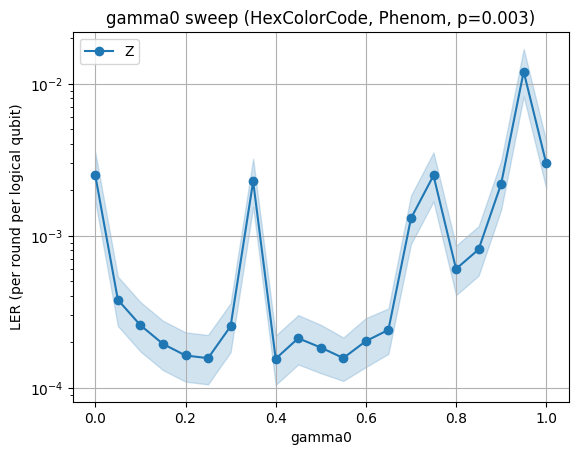

In [9]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=gamma0_sweep_stats,
    group_func=lambda stat: stat.json_metadata["basis"],
    failure_units_per_shot_func=lambda _: rounds,
    failure_values_func=lambda _: k,
    x_func=lambda stat: stat.json_metadata["gamma0"],
)
ax.semilogy()
ax.grid()
ax.set_ylabel("LER (per round per logical qubit)")
ax.set_xlabel("gamma0")
ax.set_title(f"gamma0 sweep ({code_name}, {noise_model}, p={opt_error_rate})")
ax.legend()

plt.show()

In [10]:
# Pick the best gamma0 (manually from the plot above)
gamma0_star = 0.55  # <-- UPDATE THIS after inspecting the plot

## Phase 2 — Optimization of gamma_dist_interval

In [13]:
import nevergrad as ng

opt_budget = 100
opt_raw_shots = 600_000


In [14]:
sampler = opt_expmt.dem.compile_sampler()
syndromes, observables, _ = sampler.sample(opt_raw_shots)
syndromes, observables = syndromes.astype(np.uint8), observables.astype(np.uint8)

# Only use samples that fail MemBP to train RelayBP
membp = MemBPDecoder(
    opt_expmt.chkmat,
    opt_expmt.prior,
    gamma=gamma0_star,
    max_iter=pre_iter,
)
ehat = membp.decode_batch(syndromes, parallel=True)
predicted_observables = (ehat @ opt_expmt.obsmat.T) % 2
mask = np.any(observables != predicted_observables, axis=1)
print(
    f"For basis {basis}, out of {opt_raw_shots} there are {np.sum(mask)} failing MemBP shots to train with."
)
training_data = (syndromes[mask], observables[mask])


For basis Z, out of 600000 there are 1054 failing MemBP shots to train with.


In [16]:
def cost_function(gdi_low: float, gdi_high: float) -> float:
    """Return the logical error rate for a given gamma_dist_interval."""
    print(f"Starting cost evaluation for {(gdi_low, gdi_high)}.")

    decoder = relay_bp.RelayDecoderF64(
        opt_expmt.chkmat,
        opt_expmt.prior,
        gamma0=gamma0_star,
        gamma_dist_interval=(gdi_low, gdi_high),
        num_sets=num_relays,
        pre_iter=pre_iter,
        set_max_iter=max_iter_per_relay,
        stop_nconv=stop_nconv,
    )
    observable_decoder = relay_bp.ObservableDecoderRunner(
        decoder,
        opt_expmt.obsmat,
        include_decode_result=False,
    )

    syndromes, observables = training_data
    predicted_observables = observable_decoder.decode_observables_batch(
        syndromes, parallel=True
    )
    errors = np.sum(np.any(observables != predicted_observables, axis=1))
    ler_per_shot = errors / opt_raw_shots
    ler_per_round_per_logical_qubit = ler_per_shot / (rounds * k)
    return ler_per_round_per_logical_qubit

In [17]:
init_gamma_dist_interval = (-0.25, 0.75)

params = ng.p.Instrumentation(
    gdi_low=ng.p.Scalar(init=init_gamma_dist_interval[0], lower=-0.5, upper=0.5),
    gdi_high=ng.p.Scalar(init=init_gamma_dist_interval[1], lower=0.0, upper=1.0),
)


def ensure_gamma_interval_ordered(vals):
    param_dict = vals[1]
    return param_dict["gdi_low"] < param_dict["gdi_high"]


params.register_cheap_constraint(ensure_gamma_interval_ordered)

optimizer = ng.optimizers.TwoPointsDE(parametrization=params, budget=opt_budget)
optimizer.register_callback("tell", ng.callbacks.ProgressBar())

recommendation = optimizer.minimize(cost_function, verbosity=2)

gdi_star = (recommendation[1]["gdi_low"].value, recommendation[1]["gdi_high"].value)
print(f"Optimized gamma_dist_interval: {gdi_star}")
print(f"LER per round per logical qubit: {cost_function(*gdi_star)}")

Launching 1 jobs with new suggestions
Starting cost evaluation for (-0.28083337098050953, 0.9845757580981256).


0it [00:00, ?it/s]

Updating fitness with value 4.5454545454545457e-07
99 remaining budget and 0 running jobs
Current pessimistic best is: MultiValue<mean: 4.5454545454545457e-07, count: 1, parameter: Instrumentation(Tuple(),Dict(gdi_high=Scalar{Cl(0,1,b)}[sigma=Scalar{exp=2.03}],gdi_low=Scalar{Cl(-0.5,0.5,b)}[sigma=Scalar{exp=2.03}])):((), {'gdi_low': -0.28083337098050953, 'gdi_high': 0.9845757580981256})>
Launching 1 jobs with new suggestions
Starting cost evaluation for (-0.2539195696228849, 0.7529741606377289).


  2%|▏         | 2/100 [00:03<03:04,  1.88s/it]

Updating fitness with value 9.090909090909091e-07
98 remaining budget and 0 running jobs
Current pessimistic best is: MultiValue<mean: 4.5454545454545457e-07, count: 1, parameter: Instrumentation(Tuple(),Dict(gdi_high=Scalar{Cl(0,1,b)}[sigma=Scalar{exp=2.03}],gdi_low=Scalar{Cl(-0.5,0.5,b)}[sigma=Scalar{exp=2.03}])):((), {'gdi_low': -0.28083337098050953, 'gdi_high': 0.9845757580981256})>
Launching 1 jobs with new suggestions
Starting cost evaluation for (-0.22569395816271207, 0.8764349186579763).


...

Updating fitness with value 3.0303030303030305e-07
2 remaining budget and 0 running jobs
Current pessimistic best is: MultiValue<mean: 0.0, count: 1, parameter: Instrumentation(Tuple(),Dict(gdi_high=Scalar{Cl(0,1,b)}[sigma=Scalar{exp=2.03}],gdi_low=Scalar{Cl(-0.5,0.5,b)}[sigma=Scalar{exp=2.03}])):((), {'gdi_low': -0.21295457674166532, 'gdi_high': 0.697918233656232})>
Launching 1 jobs with new suggestions
Starting cost evaluation for (-0.18881875217114266, 0.7979575920446168).


 99%|█████████▉| 99/100 [10:49<00:06,  6.51s/it]

Updating fitness with value 4.5454545454545457e-07
1 remaining budget and 0 running jobs
Current pessimistic best is: MultiValue<mean: 0.0, count: 1, parameter: Instrumentation(Tuple(),Dict(gdi_high=Scalar{Cl(0,1,b)}[sigma=Scalar{exp=2.03}],gdi_low=Scalar{Cl(-0.5,0.5,b)}[sigma=Scalar{exp=2.03}])):((), {'gdi_low': -0.21295457674166532, 'gdi_high': 0.697918233656232})>
Launching 1 jobs with new suggestions
Starting cost evaluation for (-0.2772641641956539, 0.7966578693019218).


100%|██████████| 100/100 [10:55<00:00,  6.35s/it]

Updating fitness with value 6.060606060606061e-07
0 remaining budget and 0 running jobs
Current pessimistic best is: MultiValue<mean: 0.0, count: 1, parameter: Instrumentation(Tuple(),Dict(gdi_high=Scalar{Cl(0,1,b)}[sigma=Scalar{exp=2.03}],gdi_low=Scalar{Cl(-0.5,0.5,b)}[sigma=Scalar{exp=2.03}])):((), {'gdi_low': -0.21295457674166532, 'gdi_high': 0.697918233656232})>
Optimized gamma_dist_interval: (-0.21295457674166532, 0.697918233656232)
Starting cost evaluation for (-0.21295457674166532, 0.697918233656232).
LER per round per logical qubit: 0.0
